# UNIVERSIDAD AUTONOMA DE OCCIDENTE

## Maestría en Inteligencia Artificial y Ciencia de Datos  

**Asignatura:** Gestion de proyectos en IA y CD

**Profesor:** Juan Manuel Nuñez Velasco

**Laboratorio 1:**  Projecto de Clasificacion Frijol

**Integrantes:**  
- Viviana Valle Fernandez - Cod
- Juan Guillermo Gomez Torres - Cod
- Sebastián Urquijo Buitrago - Cod 22500251

# 01 - Análisis Exploratorio de Datos EDA del Dataset Dry Bean

## Objetivo del notebook

Este notebook tiene como propósito realizar el análisis exploratorio inicial del dataset Dry Bean, validando su correcta carga, estructura, calidad y consistencia antes de avanzar hacia etapas posteriores de limpieza, preprocesamiento y entrenamiento de modelos de clasificación.

El flujo de trabajo incluirá:

- Configuración del entorno de trabajo.
- Definición de rutas del proyecto.
- Validación de existencia del dataset local.
- Carga del dataset en memoria.
- Revisión inicial de estructura, dimensiones y tipos de datos.
- Análisis de calidad de datos.
- Limpieza y generación de una versión procesada del dataset.

Este notebook hace parte de un proyecto de clasificación supervisada, donde la variable objetivo corresponde a la clase o tipo de frijol.

In [1]:
# ==========================================
# 1. CONFIGURACIÓN INICIAL DEL ENTORNO
# ==========================================

from pathlib import Path
import sys
import os

import pandas as pd
import numpy as np

# Configuración visual básica de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [4]:
# ==========================================
# 2. DEFINICIÓN DE RUTAS DEL PROYECTO
# ==========================================

from pathlib import Path

# Ruta real del proyecto
PROJECT_ROOT = Path(r"D:\LABORATORIO_DRYBEAN_ML")

# Rutas principales
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
SRC_DIR = PROJECT_ROOT / "src"

# Mostrar rutas
print("Ruta base del proyecto:", PROJECT_ROOT)
print("Carpeta data:", DATA_DIR)
print("Carpeta raw:", RAW_DATA_DIR)
print("Carpeta processed:", PROCESSED_DATA_DIR)
print("Carpeta outputs:", OUTPUTS_DIR)
print("Carpeta notebooks:", NOTEBOOKS_DIR)
print("Carpeta src:", SRC_DIR)

Ruta base del proyecto: D:\LABORATORIO_DRYBEAN_ML
Carpeta data: D:\LABORATORIO_DRYBEAN_ML\data
Carpeta raw: D:\LABORATORIO_DRYBEAN_ML\data\raw
Carpeta processed: D:\LABORATORIO_DRYBEAN_ML\data\processed
Carpeta outputs: D:\LABORATORIO_DRYBEAN_ML\outputs
Carpeta notebooks: D:\LABORATORIO_DRYBEAN_ML\notebooks
Carpeta src: D:\LABORATORIO_DRYBEAN_ML\src


In [5]:
# ==========================================
# 3. VALIDACIÓN DE CARPETAS DEL PROYECTO
# ==========================================

required_dirs = [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    OUTPUTS_DIR,
    NOTEBOOKS_DIR,
    SRC_DIR
]

for directory in required_dirs:
    if directory.exists():
        print(f"Existe: {directory}")
    else:
        print(f"No existe, se creará: {directory}")
        directory.mkdir(parents=True, exist_ok=True)

print("Validación de carpetas finalizada.")

Existe: D:\LABORATORIO_DRYBEAN_ML\data
Existe: D:\LABORATORIO_DRYBEAN_ML\data\raw
Existe: D:\LABORATORIO_DRYBEAN_ML\data\processed
Existe: D:\LABORATORIO_DRYBEAN_ML\outputs
Existe: D:\LABORATORIO_DRYBEAN_ML\notebooks
Existe: D:\LABORATORIO_DRYBEAN_ML\src
Validación de carpetas finalizada.


# 02 - Validación y extracción del dataset

En esta sección se valida la existencia del archivo comprimido del dataset Dry Bean almacenado localmente en la carpeta `data/raw`.

Posteriormente, se inspeccionará el contenido interno del archivo `.zip` y se realizará su extracción para facilitar el proceso de carga y análisis exploratorio de datos.

In [7]:
# ==========================================
# 4. VALIDACIÓN DEL ARCHIVO ZIP
# ==========================================

ZIP_FILENAME = "dry+bean+dataset.zip"

ZIP_FILE_PATH = RAW_DATA_DIR / ZIP_FILENAME

print("Ruta esperada del archivo ZIP:")
print(ZIP_FILE_PATH)

# Validar existencia
if ZIP_FILE_PATH.exists():
    print("\nArchivo ZIP encontrado correctamente.")
else:
    raise FileNotFoundError(
        f"No se encontró el archivo: {ZIP_FILE_PATH}"
    )

Ruta esperada del archivo ZIP:
D:\LABORATORIO_DRYBEAN_ML\data\raw\dry+bean+dataset.zip

Archivo ZIP encontrado correctamente.


In [8]:
# ==========================================
# 5. INSPECCIÓN DEL CONTENIDO DEL ZIP
# ==========================================

import zipfile

with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    
    zip_content = zip_ref.namelist()

    print("Contenido encontrado dentro del ZIP:\n")

    for file in zip_content:
        print(file)

Contenido encontrado dentro del ZIP:

DryBeanDataset/
DryBeanDataset/Dry_Bean_Dataset.arff
DryBeanDataset/Dry_Bean_Dataset.txt
DryBeanDataset/Dry_Bean_Dataset.xlsx


# 03 - Extracción del dataset

Después de validar el contenido del archivo comprimido, se procede a extraer el dataset en formato Excel (`.xlsx`) dentro de la carpeta `data/raw`.

El archivo Excel será utilizado como fuente principal para el análisis exploratorio y el posterior procesamiento de datos.

In [9]:
# ==========================================
# 6. EXTRACCIÓN DEL DATASET
# ==========================================

import zipfile

with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    
    zip_ref.extractall(RAW_DATA_DIR)

print("Dataset extraído correctamente.")

Dataset extraído correctamente.


In [10]:
# ==========================================
# 7. DEFINICIÓN DE LA RUTA DEL DATASET
# ==========================================

DATASET_PATH = (
    RAW_DATA_DIR
    / "DryBeanDataset"
    / "Dry_Bean_Dataset.xlsx"
)

print("Ruta esperada del dataset:")
print(DATASET_PATH)

# Validar existencia
if DATASET_PATH.exists():
    print("\nDataset encontrado correctamente.")
else:
    raise FileNotFoundError(
        f"No se encontró el dataset: {DATASET_PATH}"
    )

Ruta esperada del dataset:
D:\LABORATORIO_DRYBEAN_ML\data\raw\DryBeanDataset\Dry_Bean_Dataset.xlsx

Dataset encontrado correctamente.


In [11]:
# ==========================================
# 8. VALIDACIÓN DEL TAMAÑO DEL ARCHIVO
# ==========================================

file_size_mb = DATASET_PATH.stat().st_size / (1024 * 1024)

print(f"Tamaño del dataset: {file_size_mb:.2f} MB")

Tamaño del dataset: 2.90 MB


# 04 - Carga y exploración inicial del dataset

En esta sección se realiza la carga del dataset Dry Bean en memoria utilizando la librería pandas.

Posteriormente, se llevará a cabo una exploración preliminar para identificar:

- Número de registros y columnas.
- Nombres de variables.
- Tipos de datos.
- Estructura general del dataset.
- Vista inicial de observaciones.

Esta etapa permite comprender la composición del conjunto de datos antes de iniciar el análisis de calidad y limpieza.

## Instalación de dependencias para lectura de archivos Excel

El dataset se encuentra en formato `.xlsx`, por lo tanto es necesario instalar la librería `openpyxl`, utilizada por pandas como motor de lectura de archivos Excel.

Esta dependencia permitirá cargar correctamente el dataset en memoria.

In [ ]:
!pip install openpyxl

In [13]:
# ==========================================
# 9. CARGA DEL DATASET EN MEMORIA
# ==========================================

df = pd.read_excel(DATASET_PATH)

print("Dataset cargado correctamente en memoria.")

Dataset cargado correctamente en memoria.


In [14]:
# ==========================================
# 10. DIMENSIONES DEL DATASET
# ==========================================

rows, cols = df.shape

print(f"Número de registros: {rows}")
print(f"Número de columnas: {cols}")

Número de registros: 13611
Número de columnas: 17


In [15]:
# ==========================================
# 11. VISTA PRELIMINAR DEL DATASET
# ==========================================

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.2910,208.1781,173.8887,1.1972,0.5498,28715,190.1411,0.7639,0.9889,0.9580,0.9134,0.0073,0.0031,0.8342,0.9987,SEKER
1,28734,638.0180,200.5248,182.7344,1.0974,0.4118,29172,191.2728,0.7840,0.9850,0.8870,0.9539,0.0070,0.0036,0.9099,0.9984,SEKER
2,29380,624.1100,212.8261,175.9311,1.2097,0.5627,29690,193.4109,0.7781,0.9896,0.9478,0.9088,0.0072,0.0030,0.8259,0.9991,SEKER
3,30008,645.8840,210.5580,182.5165,1.1536,0.4986,30724,195.4671,0.7827,0.9767,0.9039,0.9283,0.0070,0.0032,0.8618,0.9942,SEKER
4,30140,620.1340,201.8479,190.2793,1.0608,0.3337,30417,195.8965,0.7731,0.9909,0.9849,0.9705,0.0067,0.0037,0.9419,0.9992,SEKER


In [16]:
# ==========================================
# 12. NOMBRES DE LAS COLUMNAS
# ==========================================

print("Columnas del dataset:\n")

for idx, column in enumerate(df.columns, start=1):
    print(f"{idx}. {column}")

Columnas del dataset:

1. Area
2. Perimeter
3. MajorAxisLength
4. MinorAxisLength
5. AspectRation
6. Eccentricity
7. ConvexArea
8. EquivDiameter
9. Extent
10. Solidity
11. roundness
12. Compactness
13. ShapeFactor1
14. ShapeFactor2
15. ShapeFactor3
16. ShapeFactor4
17. Class


In [17]:
# ==========================================
# 13. TIPOS DE DATOS
# ==========================================

df.dtypes

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

In [18]:
# ==========================================
# 14. INFORMACIÓN GENERAL DEL DATASET
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

# 05 - Análisis de calidad de datos

En esta sección se realiza una evaluación inicial de la calidad del dataset con el propósito de identificar posibles inconsistencias que puedan afectar el entrenamiento de modelos de Machine Learning.

Las validaciones incluyen:

- Identificación de valores faltantes.
- Detección de registros duplicados.
- Análisis de distribución de clases.
- Estadísticas descriptivas.
- Revisión de consistencia estructural.

## 5.1 Identificación de valores faltantes

Se analiza la presencia de valores nulos en cada variable del dataset para validar la integridad de la información y detectar posibles problemas de calidad de datos.

In [19]:
# ==========================================
# 15. VALIDACIÓN DE VALORES NULOS
# ==========================================

null_values = df.isnull().sum()

null_summary = pd.DataFrame({
    "Columna": null_values.index,
    "Valores_Nulos": null_values.values,
    "Porcentaje_Nulos": (
        null_values.values / len(df)
    ) * 100
})

null_summary

,Columna,Valores_Nulos,Porcentaje_Nulos
0,Area,0,0.0000
1,Perimeter,0,0.0000
2,MajorAxisLength,0,0.0000
3,MinorAxisLength,0,0.0000
4,AspectRation,0,0.0000
5,Eccentricity,0,0.0000
6,ConvexArea,0,0.0000
7,EquivDiameter,0,0.0000
8,Extent,0,0.0000
9,Solidity,0,0.0000


In [20]:
# ==========================================
# 16. RESUMEN GENERAL DE NULOS
# ==========================================

total_nulls = df.isnull().sum().sum()

print(f"Total de valores nulos en el dataset: {total_nulls}")

Total de valores nulos en el dataset: 0


## 5.2 Detección de registros duplicados

Se verifica la existencia de registros repetidos dentro del dataset, ya que los duplicados pueden generar sesgos durante el entrenamiento y evaluación de modelos de clasificación.

In [21]:
# ==========================================
# 17. VALIDACIÓN DE DUPLICADOS
# ==========================================

duplicate_count = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicate_count}")

Cantidad de registros duplicados: 68


In [22]:
# ==========================================
# 18. VISUALIZACIÓN DE DUPLICADOS
# ==========================================

if duplicate_count > 0:
    
    duplicated_rows = df[df.duplicated()]
    
    display(duplicated_rows.head())
    
else:
    
    print("No se encontraron registros duplicados.")

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.9560,277.5714,154.3056,1.7988,0.8312,34023,206.5828,0.8084,0.9852,0.8524,0.7443,0.0083,0.0016,0.5539,0.9964,HOROZ
5509,33954,716.7500,277.3685,156.3563,1.7740,0.8260,34420,207.9220,0.7995,0.9865,0.8305,0.7496,0.0082,0.0016,0.5619,0.9968,HOROZ
5548,38427,756.3230,306.5339,160.5918,1.9088,0.8518,38773,221.1940,0.7970,0.9911,0.8442,0.7216,0.0080,0.0013,0.5207,0.9939,HOROZ
5554,38891,791.3430,319.5000,156.8696,2.0367,0.8712,39651,222.5254,0.6500,0.9808,0.7804,0.6965,0.0082,0.0012,0.4851,0.9880,HOROZ
5599,40804,790.8020,323.4756,163.2877,1.9810,0.8632,41636,227.9326,0.7876,0.9800,0.8199,0.7046,0.0079,0.0012,0.4965,0.9836,HOROZ


## 5.3 Distribución de clases

Se analiza la distribución de la variable objetivo (`Class`) con el fin de identificar posibles desbalances entre categorías, los cuales podrían afectar el desempeño de los modelos de clasificación.

In [23]:
# ==========================================
# 19. DISTRIBUCIÓN DE CLASES
# ==========================================

class_distribution = (
    df["Class"]
    .value_counts()
    .reset_index()
)

class_distribution.columns = [
    "Clase",
    "Cantidad"
]

class_distribution["Porcentaje"] = (
    class_distribution["Cantidad"]
    / len(df)
) * 100

class_distribution

,Clase,Cantidad,Porcentaje
0,DERMASON,3546,26.0525
1,SIRA,2636,19.3667
2,SEKER,2027,14.8924
3,HOROZ,1928,14.1650
4,CALI,1630,11.9756
5,BARBUNYA,1322,9.7127
6,BOMBAY,522,3.8351


In [24]:
# ==========================================
# 20. NÚMERO DE CLASES
# ==========================================

num_classes = df["Class"].nunique()

print(f"Número de clases únicas: {num_classes}")

Número de clases únicas: 7


In [25]:
# ==========================================
# 21. CLASES DISPONIBLES
# ==========================================

classes = sorted(df["Class"].unique())

print("Clases encontradas:\n")

for idx, bean_class in enumerate(classes, start=1):
    print(f"{idx}. {bean_class}")

Clases encontradas:

1. BARBUNYA
2. BOMBAY
3. CALI
4. DERMASON
5. HOROZ
6. SEKER
7. SIRA


# 06 - Estadísticas descriptivas

En esta sección se realiza un análisis estadístico de las variables numéricas presentes en el dataset.

El objetivo es identificar:

- Tendencias centrales.
- Dispersión de datos.
- Rangos de valores.
- Posibles anomalías u outliers.
- Diferencias de escala entre variables.

Estas métricas permiten comprender mejor el comportamiento de las características utilizadas posteriormente en el entrenamiento de modelos de clasificación.

In [26]:
# ==========================================
# 22. ESTADÍSTICAS DESCRIPTIVAS GENERALES
# ==========================================

descriptive_stats = df.describe()

descriptive_stats

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000
mean,53048.2845,855.2835,320.1419,202.2707,1.5832,0.7509,53768.2002,253.0642,0.7497,0.9871,0.8733,0.7999,0.0066,0.0017,0.6436,0.9951
std,29324.0957,214.2897,85.6942,44.9701,0.2467,0.0920,29774.9158,59.1771,0.0491,0.0047,0.0595,0.0617,0.0011,0.0006,0.0990,0.0044
min,20420.0000,524.7360,183.6012,122.5127,1.0249,0.2190,20684.0000,161.2438,0.5553,0.9192,0.4896,0.6406,0.0028,0.0006,0.4103,0.9477
25%,36328.0000,703.5235,253.3036,175.8482,1.4323,0.7159,36714.5000,215.0680,0.7186,0.9857,0.8321,0.7625,0.0059,0.0012,0.5814,0.9937
50%,44652.0000,794.9410,296.8834,192.4317,1.5511,0.7644,45178.0000,238.4380,0.7599,0.9883,0.8832,0.8013,0.0066,0.0017,0.6420,0.9964
75%,61332.0000,977.2130,376.4950,217.0317,1.7071,0.8105,62294.0000,279.4465,0.7869,0.9900,0.9169,0.8343,0.0073,0.0022,0.6960,0.9979
max,254616.0000,1985.3700,738.8602,460.1985,2.4303,0.9114,263261.0000,569.3744,0.8662,0.9947,0.9907,0.9873,0.0105,0.0037,0.9748,0.9997


In [27]:
# ==========================================
# 23. ESTADÍSTICAS DESCRIPTIVAS TRANSFORMADAS
# ==========================================

descriptive_stats_transposed = (
    df.describe()
    .transpose()
)

descriptive_stats_transposed

,count,mean,std,min,25%,50%,75%,max
Area,13611.0000,53048.2845,29324.0957,20420.0000,36328.0000,44652.0000,61332.0000,254616.0000
Perimeter,13611.0000,855.2835,214.2897,524.7360,703.5235,794.9410,977.2130,1985.3700
MajorAxisLength,13611.0000,320.1419,85.6942,183.6012,253.3036,296.8834,376.4950,738.8602
MinorAxisLength,13611.0000,202.2707,44.9701,122.5127,175.8482,192.4317,217.0317,460.1985
AspectRation,13611.0000,1.5832,0.2467,1.0249,1.4323,1.5511,1.7071,2.4303
Eccentricity,13611.0000,0.7509,0.0920,0.2190,0.7159,0.7644,0.8105,0.9114
ConvexArea,13611.0000,53768.2002,29774.9158,20684.0000,36714.5000,45178.0000,62294.0000,263261.0000
EquivDiameter,13611.0000,253.0642,59.1771,161.2438,215.0680,238.4380,279.4465,569.3744
Extent,13611.0000,0.7497,0.0491,0.5553,0.7186,0.7599,0.7869,0.8662
Solidity,13611.0000,0.9871,0.0047,0.9192,0.9857,0.9883,0.9900,0.9947


## 6.1 Identificación de tipos de variables

Se separan las variables numéricas y categóricas con el propósito de facilitar análisis posteriores como correlaciones, visualizaciones y procesos de preprocesamiento.

In [28]:
# ==========================================
# 24. VARIABLES NUMÉRICAS
# ==========================================

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Variables numéricas:\n")

for idx, column in enumerate(numeric_columns, start=1):
    print(f"{idx}. {column}")

Variables numéricas:

1. Area
2. Perimeter
3. MajorAxisLength
4. MinorAxisLength
5. AspectRation
6. Eccentricity
7. ConvexArea
8. EquivDiameter
9. Extent
10. Solidity
11. roundness
12. Compactness
13. ShapeFactor1
14. ShapeFactor2
15. ShapeFactor3
16. ShapeFactor4


In [29]:
# ==========================================
# 25. VARIABLES CATEGÓRICAS
# ==========================================

categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Variables categóricas:\n")

for idx, column in enumerate(categorical_columns, start=1):
    print(f"{idx}. {column}")

Variables categóricas:

1. Class


## 6.2 Identificación preliminar de valores atípicos

Se realiza una revisión inicial de valores mínimos y máximos para detectar posibles observaciones atípicas que puedan afectar el comportamiento de los modelos de Machine Learning.

In [30]:
# ==========================================
# 26. VALORES MÍNIMOS Y MÁXIMOS
# ==========================================

min_max_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Valor_Mínimo": [
        df[col].min()
        for col in numeric_columns
    ],
    "Valor_Máximo": [
        df[col].max()
        for col in numeric_columns
    ]
})

min_max_summary

,Variable,Valor_Mínimo,Valor_Máximo
0,Area,20420.0000,254616.0000
1,Perimeter,524.7360,1985.3700
2,MajorAxisLength,183.6012,738.8602
3,MinorAxisLength,122.5127,460.1985
4,AspectRation,1.0249,2.4303
5,Eccentricity,0.2190,0.9114
6,ConvexArea,20684.0000,263261.0000
7,EquivDiameter,161.2438,569.3744
8,Extent,0.5553,0.8662
9,Solidity,0.9192,0.9947


# 07 - Visualización de la distribución de clases

En esta sección se representa gráficamente la distribución de la variable objetivo `Class`.

Este análisis permite identificar visualmente si el dataset está balanceado o si existen clases con menor representación, lo cual puede afectar el entrenamiento de modelos de clasificación.

In [32]:
# ==========================================
# 27. IMPORTACIÓN DE LIBRERÍAS DE VISUALIZACIÓN
# ==========================================

import matplotlib.pyplot as plt

print("Librerías de visualización importadas correctamente.")

Librerías de visualización importadas correctamente.


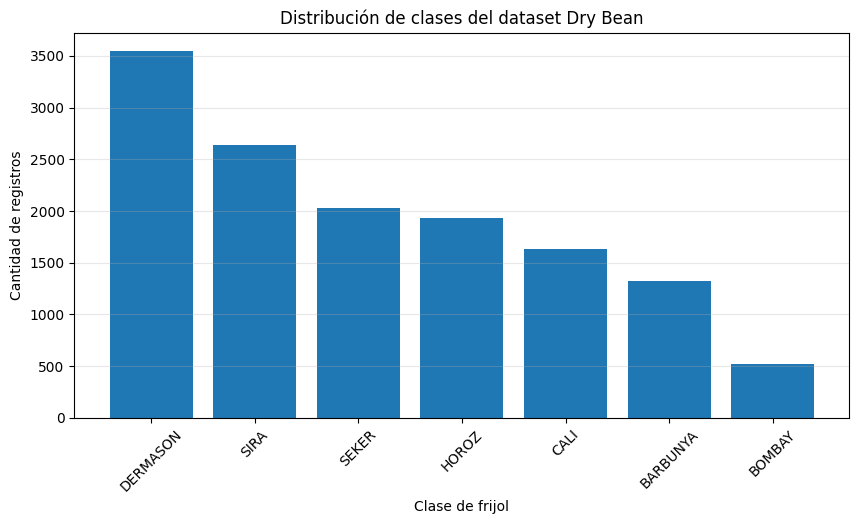

In [33]:
# ==========================================
# 28. GRÁFICO DE DISTRIBUCIÓN DE CLASES
# ==========================================

plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution["Clase"],
    class_distribution["Cantidad"]
)

plt.title("Distribución de clases del dataset Dry Bean")
plt.xlabel("Clase de frijol")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

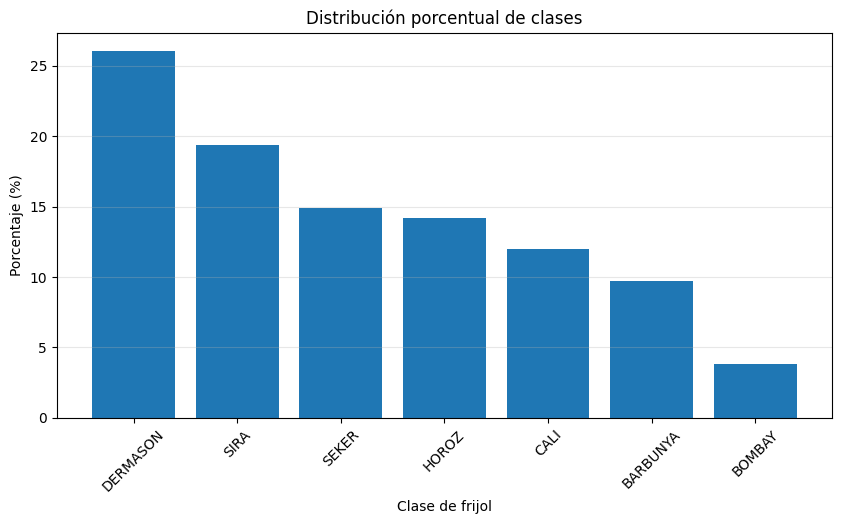

In [34]:
# ==========================================
# 29. GRÁFICO DE DISTRIBUCIÓN PORCENTUAL DE CLASES
# ==========================================

plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution["Clase"],
    class_distribution["Porcentaje"]
)

plt.title("Distribución porcentual de clases")
plt.xlabel("Clase de frijol")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

# 08 - Distribución de variables numéricas

En esta sección se analiza visualmente la distribución de las variables numéricas del dataset mediante histogramas.

Este análisis permite identificar:

- Distribuciones normales o sesgadas.
- Concentración de valores.
- Variables con alta dispersión.
- Posibles valores extremos.
- Diferencias de escala.

La comprensión de estas distribuciones es importante para seleccionar técnicas adecuadas de normalización y modelado.

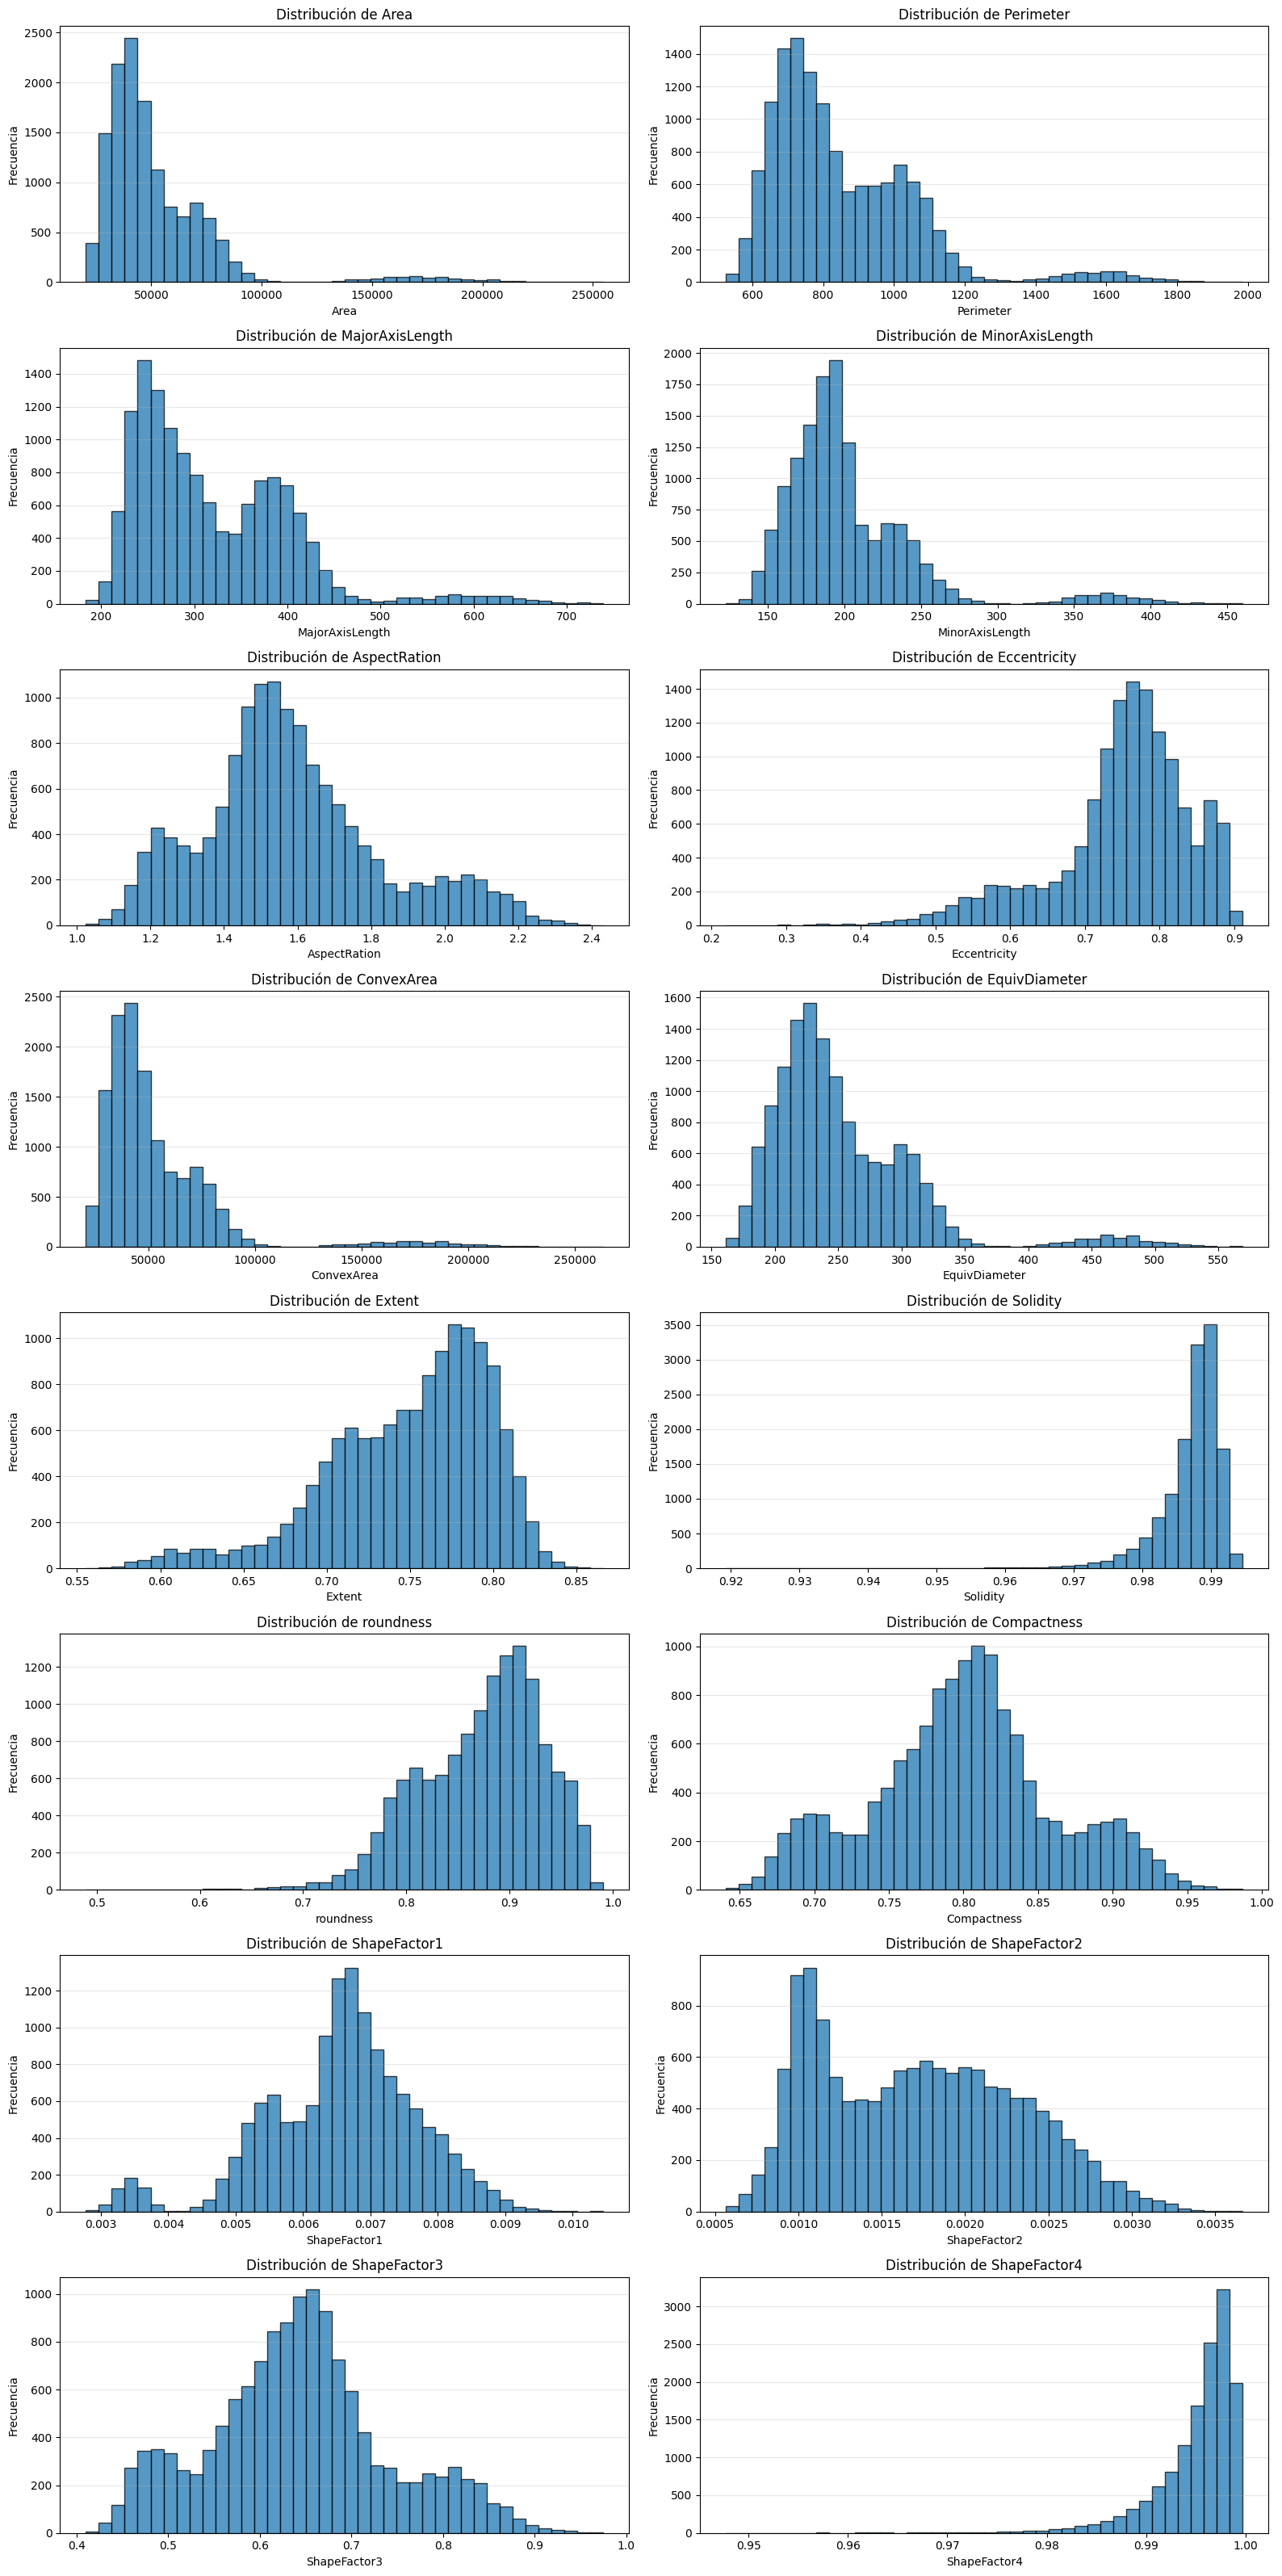

In [37]:
# ==========================================
# 30. HISTOGRAMAS DE VARIABLES NUMÉRICAS
# ==========================================

import math
import matplotlib.pyplot as plt

num_cols = len(numeric_columns)

cols = 2
rows = math.ceil(num_cols / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, rows * 4)
)

axes = axes.flatten()

for idx, column in enumerate(numeric_columns):
    
    axes[idx].hist(
        df[column],
        bins=40,
        edgecolor="black",
        alpha=0.75
    )
    
    axes[idx].set_title(f"Distribución de {column}")
    axes[idx].set_xlabel(column)
    axes[idx].set_ylabel("Frecuencia")
    axes[idx].grid(axis="y", alpha=0.3)

# Ocultar espacios vacíos si existen
for idx in range(len(numeric_columns), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# 09 - Detección visual de valores atípicos

Se utilizan diagramas de caja (boxplots) para identificar posibles valores atípicos presentes en las variables numéricas.

Los outliers pueden afectar significativamente ciertos modelos de Machine Learning, especialmente aquellos sensibles a escalas y distribuciones extremas.

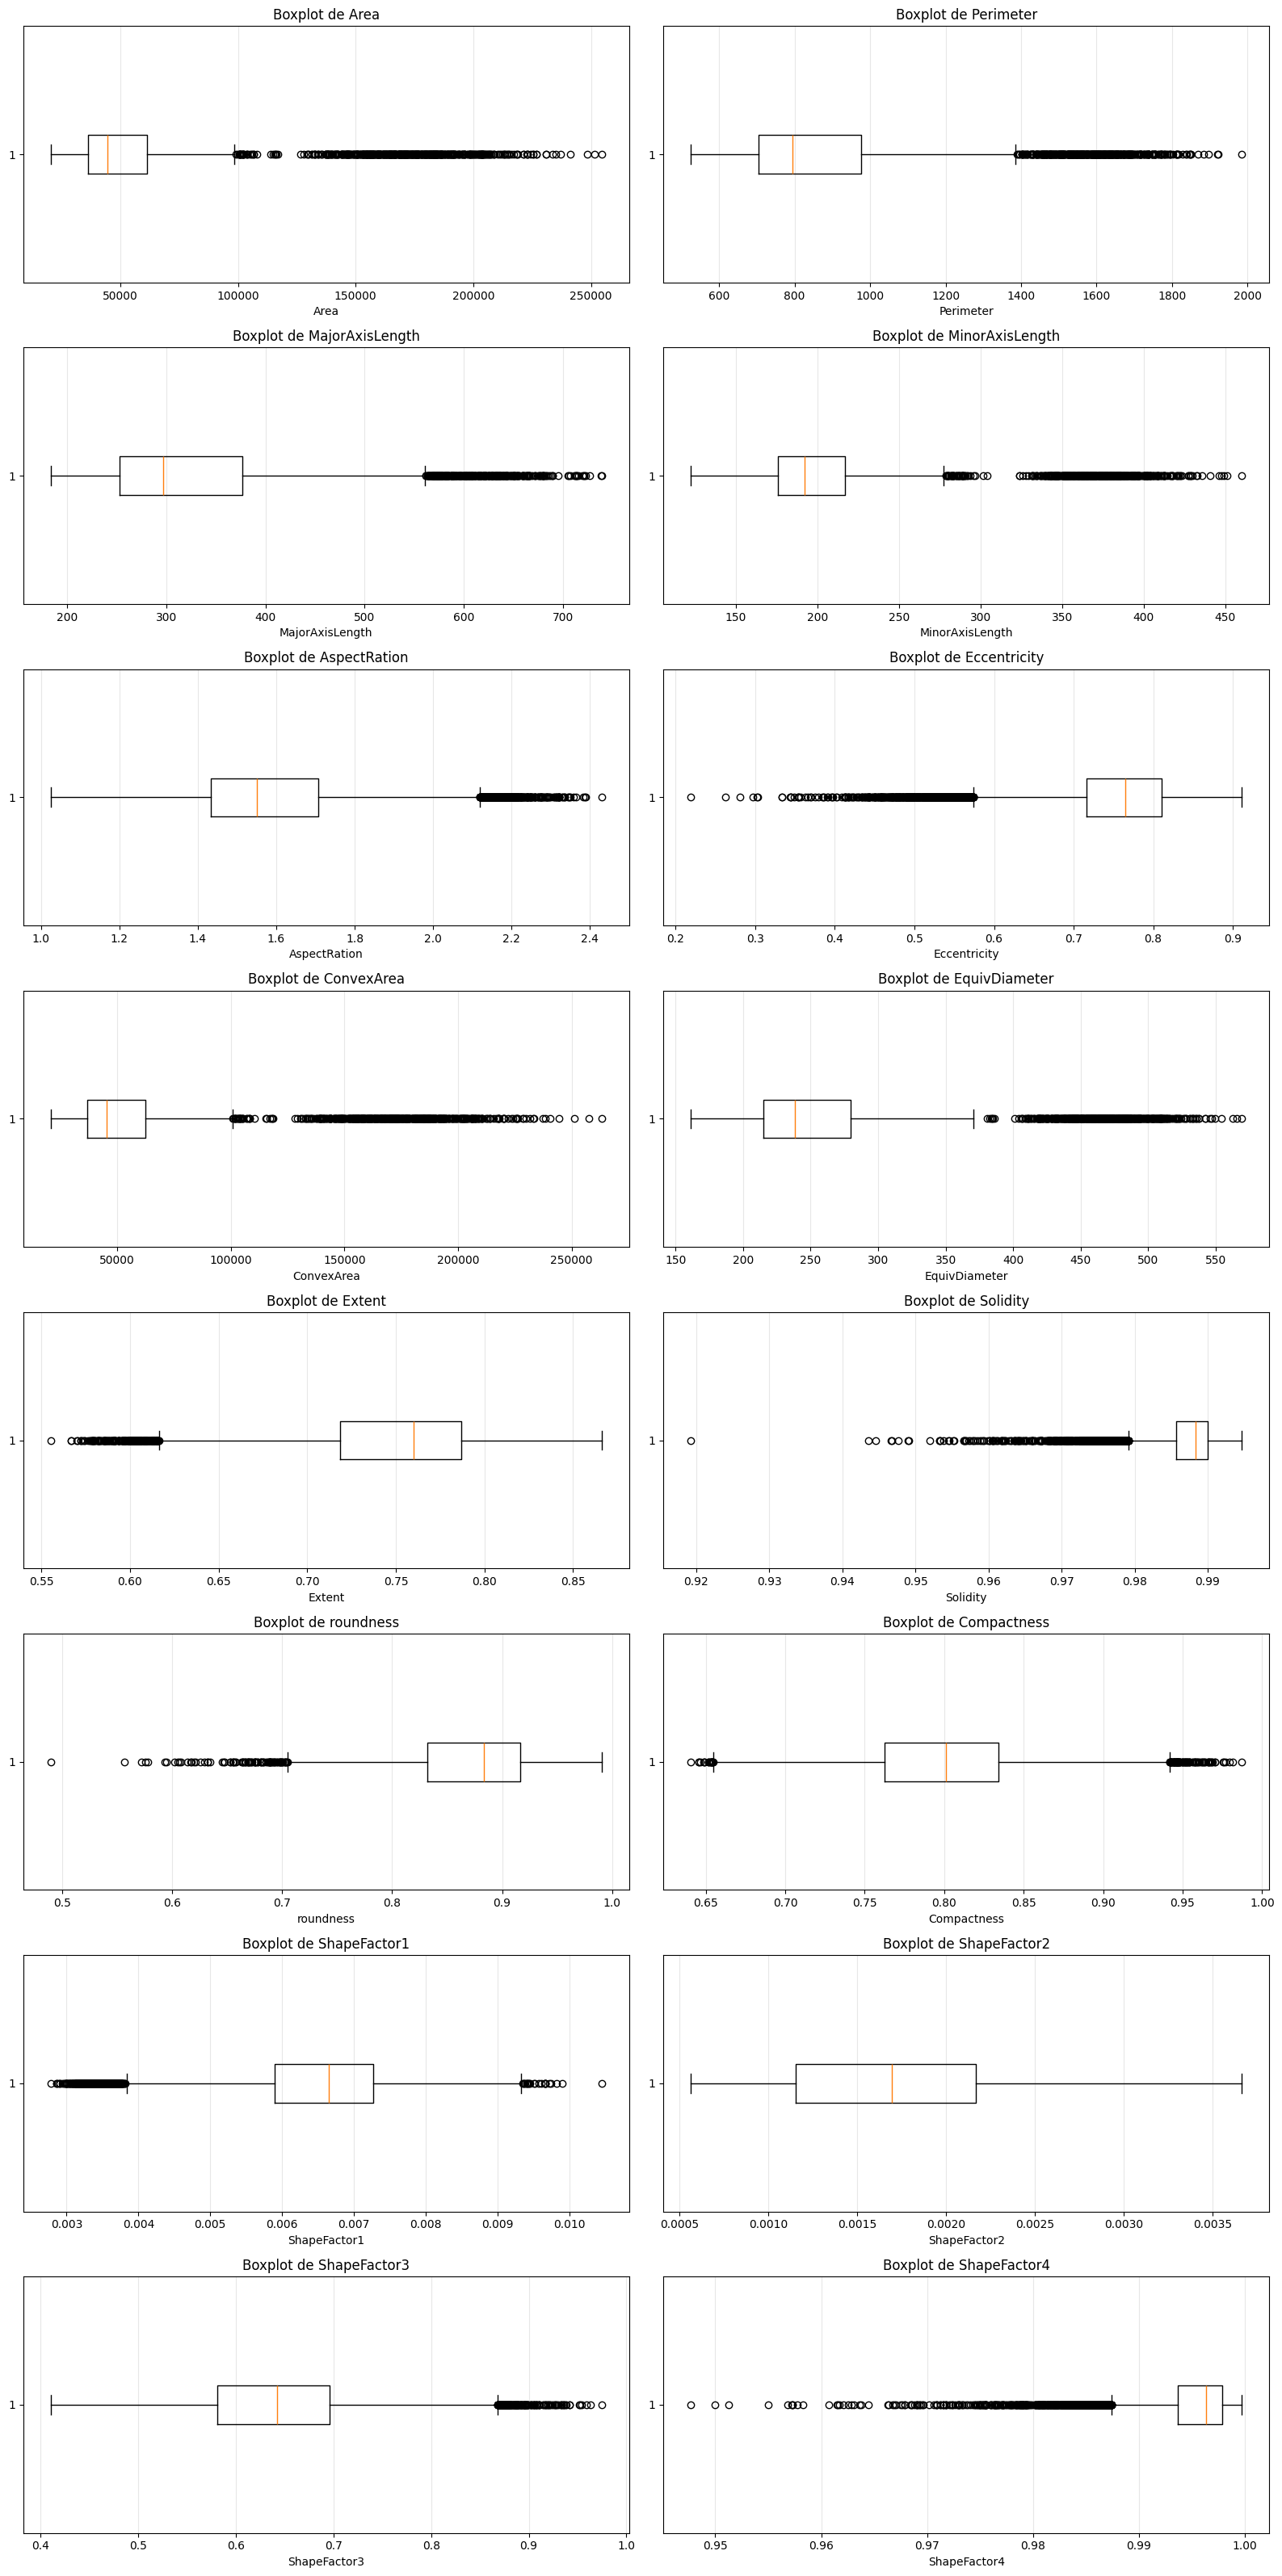

In [38]:
# ==========================================
# 31. BOXPLOTS DE VARIABLES NUMÉRICAS
# ==========================================

cols = 2
rows = math.ceil(len(numeric_columns) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, rows * 4)
)

axes = axes.flatten()

for idx, column in enumerate(numeric_columns):
    
    axes[idx].boxplot(
        df[column],
        vert=False
    )
    
    axes[idx].set_title(f"Boxplot de {column}")
    axes[idx].set_xlabel(column)
    axes[idx].grid(axis="x", alpha=0.3)

# Ocultar espacios vacíos si existen
for idx in range(len(numeric_columns), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## Agrupación de variables según escala

Para mejorar la interpretación visual, las variables se agrupan según su magnitud:

- Variables de tamaño o dimensión.
- Variables de proporción o forma.
- Factores de forma.

In [39]:
# ==========================================
# 32. AGRUPACIÓN DE VARIABLES POR ESCALA
# ==========================================

size_columns = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "ConvexArea",
    "EquivDiameter"
]

ratio_columns = [
    "AspectRation",
    "Eccentricity",
    "Extent",
    "Solidity",
    "roundness",
    "Compactness"
]

shape_factor_columns = [
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor3",
    "ShapeFactor4"
]

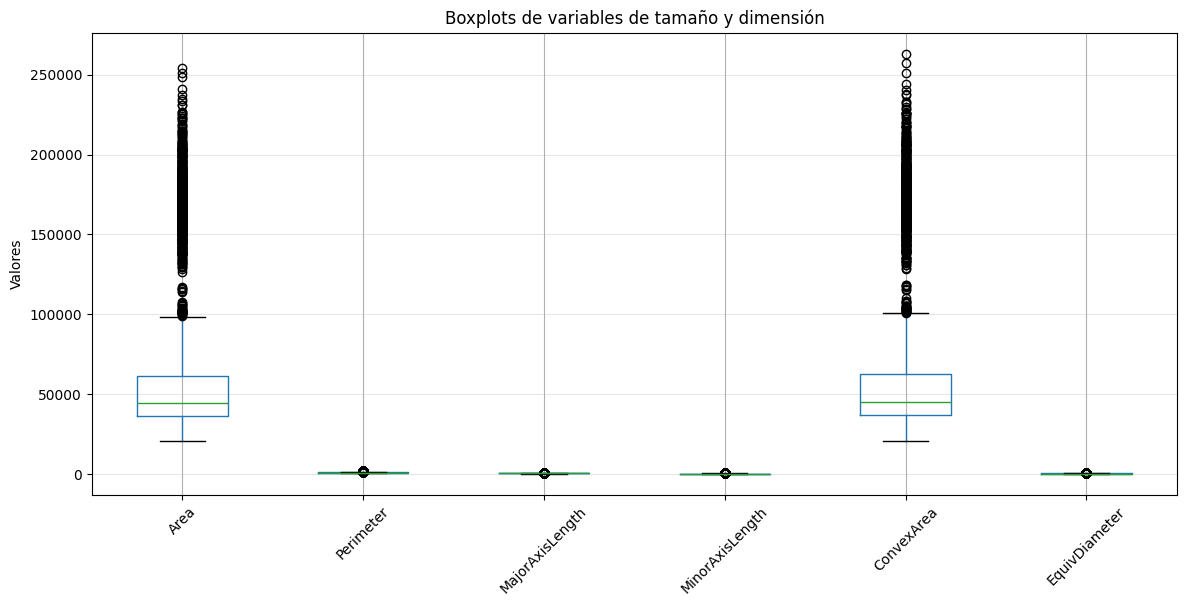

In [41]:
# ==========================================
# 33. BOXPLOT VARIABLES DE TAMAÑO
# ==========================================

plt.figure(figsize=(14, 6))

df[size_columns].boxplot(rot=45)

plt.title("Boxplots de variables de tamaño y dimensión")
plt.ylabel("Valores")
plt.grid(axis="y", alpha=0.3)

plt.show()

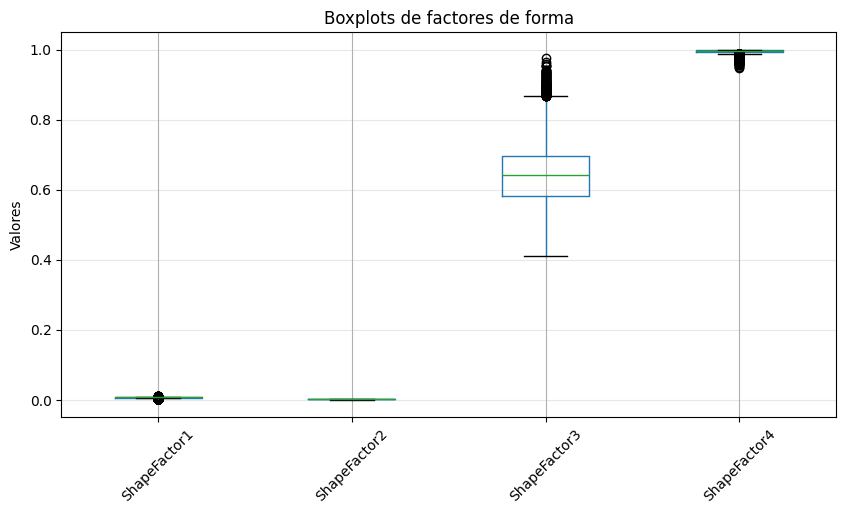

In [42]:
# ==========================================
# 35. BOXPLOT SHAPE FACTORS
# ==========================================

plt.figure(figsize=(10, 5))

df[shape_factor_columns].boxplot(rot=45)

plt.title("Boxplots de factores de forma")
plt.ylabel("Valores")
plt.grid(axis="y", alpha=0.3)

plt.show()

# 10 - Análisis de correlaciones

En esta sección se analiza la relación entre variables numéricas mediante una matriz de correlación.

Este análisis permite identificar:

- Variables altamente relacionadas.
- Posibles redundancias.
- Multicolinealidad.
- Dependencias lineales entre características.

Comprender estas relaciones es importante para etapas posteriores de selección de variables y entrenamiento de modelos.